In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, Qwen2_5_VLProcessor
import torch

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="cuda",
    torch_dtype=torch.bfloat16,
)

processor = Qwen2_5_VLProcessor.from_pretrained(model_id)
print("Successfully loaded the model")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


Successfully loaded the model


In [2]:
adapter_path = "qwen2-7b-instruct-trl-sft-NEW"
model.load_adapter(adapter_path)

In [3]:
from PIL import Image
import json

system_message = """You are a Vision Language Model specialized in detecting clues of fire, smoke and surrounding context then classify them as no fire, dangerous fire or controlled fire.
Your task is to analyze the provided image and respond to queries with concise answers, usually a json format of a caption and a label.
Summarize what you see in the image. Describe the environment, key objects, people, and any signs of fire or smoke.
Based on your summary, classify the fire situation: no fire(e.g., fire alarm, fire distinguisher,..), controlled fire (e.g., fireplace emitting, campfire, cooking, candles, match stick, lighter..) or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)
Focus on delivering accurate, succinct caption and precise label based on the visual information. Add a brief explanation for your choice of label in the caption if necessary."""

user_query = """Summarize this situation in the image, look for signs of fire and smoke and classify whether the situation is 
no fire(e.g., fire alarm, fire distinguisher,..), 
controlled fire (e.g., fireplace emitting, campfire, cooking, candles, match stick, lighter..) 
or a dangerous/uncontrolled fire (e.g., curtains on fire, smoke on ceiling, couch on fire, bed sheet on fire, spreading fire on furniture..)
Add a brief explanation for your choice of label in the caption if necessary.
Respond only this json format:
{ \"caption\": \"...\", \"label\": \"no fire\"|\"controlled fire\"|\"dangerous fire\" }
"""

def format_data(sample):
    return [
        {
            "role": "system",
            "content": [{"type": "text", "text": system_message}],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": f"file://{sample['image_path']}",
                },
                {
                    "type": "text",
                    "text": user_query,
                },
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": f"""```json\n{json.dumps({"caption": sample["caption"], "label": sample["label"]}, ensure_ascii=False)}\n```"""
                }
            ],
        },
    ]


In [4]:
from qwen_vl_utils import process_vision_info
import pandas as pd

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Apply full chat template including system message
    text_input = processor.apply_chat_template(
        sample, tokenize=False, add_generation_prompt=True
    )

    # Process the visual input
    image_inputs, _ = process_vision_info(sample)

    # Prepare model inputs
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)

    # Generate response
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim input tokens from generated output
    trimmed_generated_ids = [out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)]

    # Decode to string
    output_text = processor.batch_decode(
        trimmed_generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )

    return output_text[0]

train_df = pd.read_csv("train_labels.csv")
train_dataset = [format_data(sample) for sample in train_df.to_dict('records')]

output = generate_text_from_sample(model, processor, train_dataset[0])
output

'```json\n{"caption": "The image depicts a computer setup on a desk with a monitor displaying a game, a keyboard, a mouse, and an open computer tower. A hand is holding a lit candle next to the computer tower, which has exposed wires and components.", "label": "controlled fire"}\n```'

# Alright, let's test

In [5]:
# Load ground truth data
df = pd.read_csv('test_labels.csv')
df.head(10)

,image_path,label,caption
0,fine_tune_dataset/test/images/test_1.jpg,dangerous fire,The image shows a close-up view of an electric...
1,fine_tune_dataset/test/images/test_2.jpg,controlled fire,"The image shows a narrow, dark tunnel with a b..."
2,fine_tune_dataset/test/images/test_3.jpg,controlled fire,The image shows a nighttime camping scene with...
3,fine_tune_dataset/test/images/test_4.jpg,controlled fire,A piece of paper is being burned on a white pl...
4,fine_tune_dataset/test/images/test_5.jpg,no fire,The image shows a small room with a white wall...
5,fine_tune_dataset/test/images/test_6.jpg,controlled fire,The image shows a person walking towards a cam...
6,fine_tune_dataset/test/images/test_7.jpg,no fire,The image shows a hallway leading to a room wi...
7,fine_tune_dataset/test/images/test_8.jpg,controlled fire,The image shows a snowy landscape with trees c...
8,fine_tune_dataset/test/images/test_9.jpg,controlled fire,The image shows a small wooden structure with ...
9,fine_tune_dataset/test/images/test_10.jpg,no fire,The image shows a room with a brown leather co...


In [6]:
import time, re
device = "cuda"

def process_sample(sample):
    """Process a single image and return the model's prediction, caption and inference time"""
    try:
        # Start timing
        start_time = time.time()
        
        clean_output = generate_text_from_sample(model, processor, sample)
        
        # Match the last complete JSON block
        matches = re.findall(r'\{[^{}]+\}', clean_output, re.DOTALL)
        if matches:
            try:
                result = json.loads(matches[-1])  # take the last match (most likely correct)
                caption = result.get("caption", "").strip()
                label = result.get("label", "").strip()
            except Exception as e:
                print(f"❌ Failed to parse JSON for {sample["image_path"]}: {e}")
                caption = clean_output
                label = "unknown"
        else:
            print(f"❌ No JSON block found in output for {sample["image_path"]}")
            caption = clean_output
            label = "unknown"

        # Calculate inference time
        inference_time = time.time() - start_time
        
        return label, caption, inference_time
            
    except Exception as e:
        # print(f"Error processing {sample["image_path"]}: {str(e)}")
        return "error", "", 0.0

In [7]:
import os
import numpy as np
# Process all images and collect predictions
predictions = []
captions = []
inference_times = []
ground_truth = []

for idx, row in df.iterrows():
    print(f"processing {row["image_path"]}")
    sample = format_data(row)
    pred, caption, inf_time = process_sample(sample)
    predictions.append(pred)
    captions.append(caption)
    inference_times.append(inf_time)
    ground_truth.append(row['label'])
    if idx % 10 == 0:
        print(f"Processed {idx} images... Average inference time so far: {np.mean(inference_times):.3f}s")

print(f"\nProcessing complete! Average inference time: {np.mean(inference_times):.3f}s")

processing fine_tune_dataset/test/images/test_1.jpg
Processed 0 images... Average inference time so far: 3.800s
processing fine_tune_dataset/test/images/test_2.jpg
processing fine_tune_dataset/test/images/test_3.jpg
processing fine_tune_dataset/test/images/test_4.jpg
processing fine_tune_dataset/test/images/test_5.jpg
processing fine_tune_dataset/test/images/test_6.jpg
processing fine_tune_dataset/test/images/test_7.jpg
processing fine_tune_dataset/test/images/test_8.jpg
processing fine_tune_dataset/test/images/test_9.jpg
processing fine_tune_dataset/test/images/test_10.jpg
processing fine_tune_dataset/test/images/test_11.jpg
Processed 10 images... Average inference time so far: 4.415s
processing fine_tune_dataset/test/images/test_12.jpg
processing fine_tune_dataset/test/images/test_13.jpg
processing fine_tune_dataset/test/images/test_14.jpg
processing fine_tune_dataset/test/images/test_15.jpg
processing fine_tune_dataset/test/images/test_16.jpg
processing fine_tune_dataset/test/images

In [8]:
# Save results to CSV
results_df = pd.DataFrame({
    'image_path': df['image_path'],
    'true_label': ground_truth,
    'predicted_label': predictions,
    'caption': captions,
    'inference_time': inference_times,
    'correct': [t == p for t, p in zip(ground_truth, predictions)]
})

results_df.to_csv('qwen2.5_vl_3B_FINE_TUNED_results.csv', index=False)
print("Results saved to qwen2.5_vl_3B_FINE_TUNED_results.csv")

Results saved to qwen2.5_vl_3B_FINE_TUNED_results.csv


In [9]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Load the CSV file
df = pd.read_csv("qwen2.5_vl_3B_FINE_TUNED_results.csv")
df = df.dropna(subset=['true_label', 'predicted_label', 'inference_time'])  # Remove rows with missing values

# Extract relevant columns
ground_truth = df['true_label'].astype(str).str.strip()
predictions = df['predicted_label'].astype(str).str.strip()
inference_times = df['inference_time'].astype(float)

# Calculate classification metrics
accuracy = accuracy_score(ground_truth, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(
    ground_truth, predictions, average='weighted'
)

# Print performance metrics
print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Inference time stats
print("\nInference Time Statistics:")
print(f"Average: {np.mean(inference_times):.3f}s")
print(f"Std Dev: {np.std(inference_times):.3f}s")
print(f"Min: {np.min(inference_times):.3f}s")
print(f"Max: {np.max(inference_times):.3f}s")

Model Performance Metrics:
Accuracy: 0.9380
Precision: 0.9449
Recall: 0.9380
F1 Score: 0.9387

Inference Time Statistics:
Average: 4.215s
Std Dev: 2.341s
Min: 0.000s
Max: 17.431s


/home/student4/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


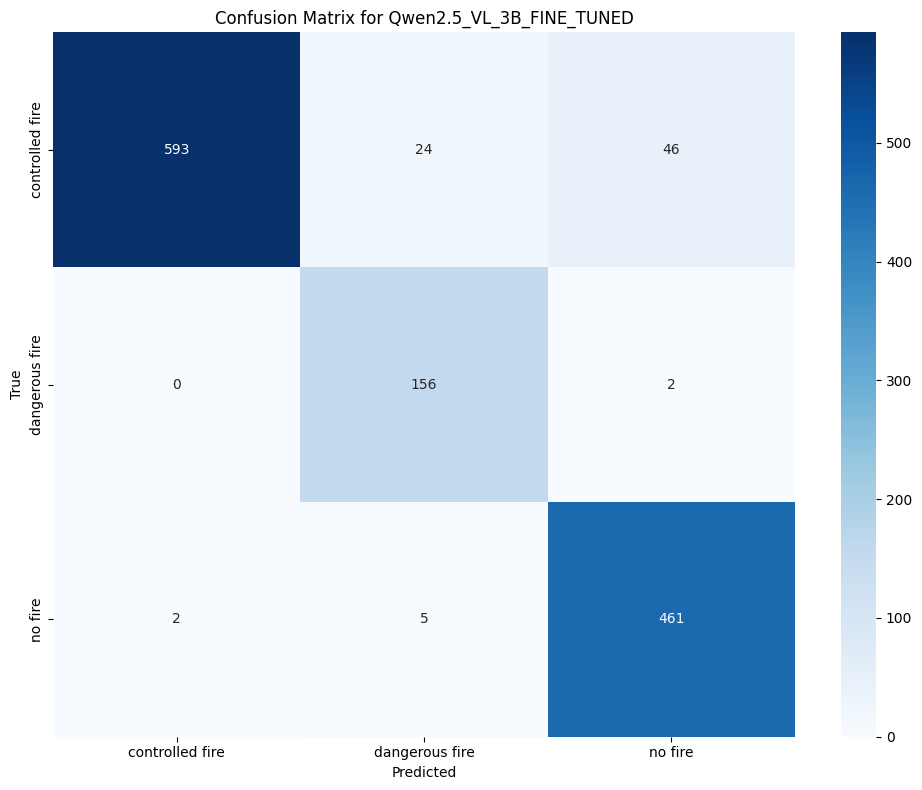

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
# Confusion matrix
labels = sorted(df['true_label'].unique())
cm = confusion_matrix(ground_truth, predictions, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix for Qwen2.5_VL_3B_FINE_TUNED')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()